Inicialización del entorno de trabajo. Importamos la librería pandas y procedemos a cargar el dataset housing.csv en un objeto DataFrame. Este paso es fundamental para poder aplicar las operaciones de análisis y transformación posteriores.

In [4]:
import pandas as pd
datos = pd.read_csv('housing.csv')

Inspección inicial de la estructura. Empleamos el método head() para visualizar un extracto de las primeras filas del conjunto de datos. Esto nos permite comprender la disposición de las columnas, los tipos de datos preliminares y el formato de los valores, estableciendo una base para el análisis exploratorio.

In [5]:
datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Análisis de frecuencias de una variable categórica. Aplicamos value_counts() a la serie ocean_proximity para obtener la distribución de frecuencias absolutas de cada categoría. Este conteo es esencial para entender la composición geográfica de los registros y detectar posibles desbalances en los datos.

In [6]:
datos["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Diagnóstico general del DataFrame. Utilizamos info() para obtener un informe detallado que incluye el número de entradas no nulas por columna, el tipo de dato (dtype) de cada una y el consumo de memoria total. Este diagnóstico es crucial para identificar valores faltantes y validar la integridad de los tipos de datos.



In [7]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Resumen estadístico descriptivo. A través de describe(), generamos un cuadro que resume las principales medidas de tendencia central (media, mediana), dispersión (desviación estándar) y rango (mínimo, máximo) para las variables numéricas. Este análisis nos da una visión cuantitativa de la distribución y escala de los datos.



In [8]:
datos.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Visualización de distribuciones univariantes. Empleamos el método hist() para construir una matriz de histogramas que muestran la frecuencia de los valores para cada atributo numérico. Esta representación gráfica nos permite inspeccionar visualmente la asimetría, la presencia de valores atípicos y la forma general de las distribuciones.



array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

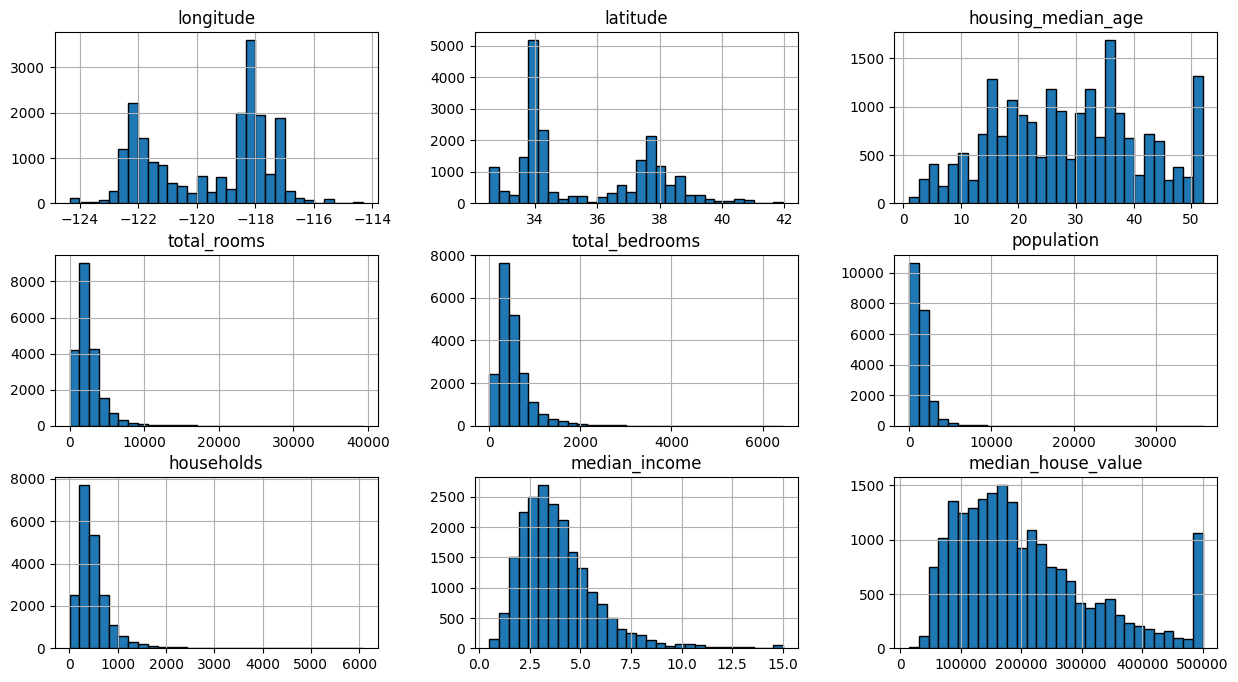

In [9]:
datos.hist(figsize=(15, 8), bins = 30, edgecolor='black')

Exploración de relaciones geoespaciales y económicas. Utilizando seaborn, construimos un gráfico de dispersión que mapea la latitud y longitud de las propiedades. El color de los puntos representa el valor de la vivienda y el tamaño, la población. Esta visualización es clave para identificar patrones de precios y densidad demográfica en las diferentes regiones.



TypeError: cannot convert the series to <class 'float'>

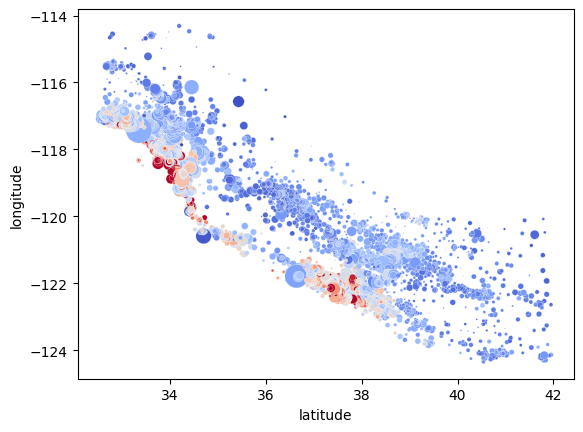

In [10]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value", palette="coolwarm",
s=datos["population"]/100)

Revisión de la estructura del dataset. Ejecutamos nuevamente info() para obtener un panorama actualizado de la integridad de los datos, confirmando la ausencia de valores nulos después de las transformaciones previas. El resumen también verifica la correcta conversión de los tipos de datos.



In [11]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Limpieza de datos: eliminación de registros incompletos. Aplicamos dropna() para generar un nuevo DataFrame, datos_na, que excluye cualquier fila que contenga un valor nulo. Este proceso asegura que los análisis posteriores se realicen sobre un conjunto de datos completo, evitando sesgos por datos ausentes.



In [12]:
datos_na = datos.dropna()

Verificación de la limpieza. Al llamar a info() sobre datos_na, confirmamos que el proceso de eliminación de filas con valores nulos ha sido exitoso, evidenciando ahora un conteo de registros no nulos consistente en todas las columnas. Esto valida la integridad del dataset limpio.



In [13]:
datos_na.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


Examen de la variable categórica. Seleccionamos la columna ocean_proximity para inspeccionar sus valores únicos y su formato. Este paso preliminar es necesario antes de aplicar técnicas de codificación que conviertan esta variable en un formato numérico adecuado para modelos de machine learning.



In [14]:
#convertir la caracteristica categorica a numerica
#Proximidad al oceano
datos_na['ocean_proximity']

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 20433, dtype: object

Cuantificación de categorías. Usamos value_counts() para obtener un recuento preciso de la ocurrencia de cada tipo de proximidad al océano. Estos conteos son fundamentales para evaluar la representatividad de las categorías y para decidir si es necesario realizar un balanceo de datos.



In [15]:
datos_na['ocean_proximity'].value_counts()
#1,2,3,4,5

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

Codificación de variables categóricas. Aplicamos la técnica de one-hot encoding mediante get_dummies() para transformar la columna ocean_proximity en un conjunto de variables binarias (dummies). Este proceso es estándar para convertir información categórica en un formato numérico utilizable por algoritmos de aprendizaje automático.



In [ ]:
#Dumies / One-Hot Encoding
# NEAR BAY  INLAND  NEAR OCEAN
#   0          0         1
dummies = pd.get_dummies(datos_na["ocean_proximity"], dtype=int)


Integración de variables transformadas. Incorporamos las nuevas columnas binarias resultantes del one-hot encoding al DataFrame datos_na utilizando join(). De esta forma, enriquecemos el dataset con representaciones numéricas de la variable categórica original, manteniendo la coherencia de los datos.



In [17]:
datos_na = datos_na.join(dummies)

Validación post-transformación. Inspeccionamos con head() las primeras filas del dataset modificado para confirmar la correcta adición de las nuevas columnas dummies. Esta verificación visual asegura que el proceso de codificación se ha aplicado sin errores.





In [18]:
datos_na.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0,0,0,1,0


Purga de la variable categórica original. Procedemos a eliminar la columna ocean_proximity mediante drop(). Una vez que sus categorías han sido representadas por las variables dummy, retirar la columna original evita redundancia y posibles multicolinealidades en el análisis.



In [19]:
datos_na = datos_na.drop(["ocean_proximity"], axis=1)

Confirmación de la estructura final. Visualizamos las primeras filas del DataFrame resultante para corroborar que el conjunto de datos ahora consta exclusivamente de atributos numéricos, listo para la fase de modelado o análisis multivariante.



In [20]:
datos_na.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


In [21]:
#Analisis, nuevas caracteristicas

Análisis de interdependencias numéricas. Construimos un mapa de calor utilizando seaborn sobre la matriz de correlación (corr()) del dataset. Este gráfico permite identificar rápidamente pares de variables con alta correlación positiva o negativa, lo cual es fundamental para entender las relaciones intrínsecas entre los atributos y para la selección de características.



<Axes: >

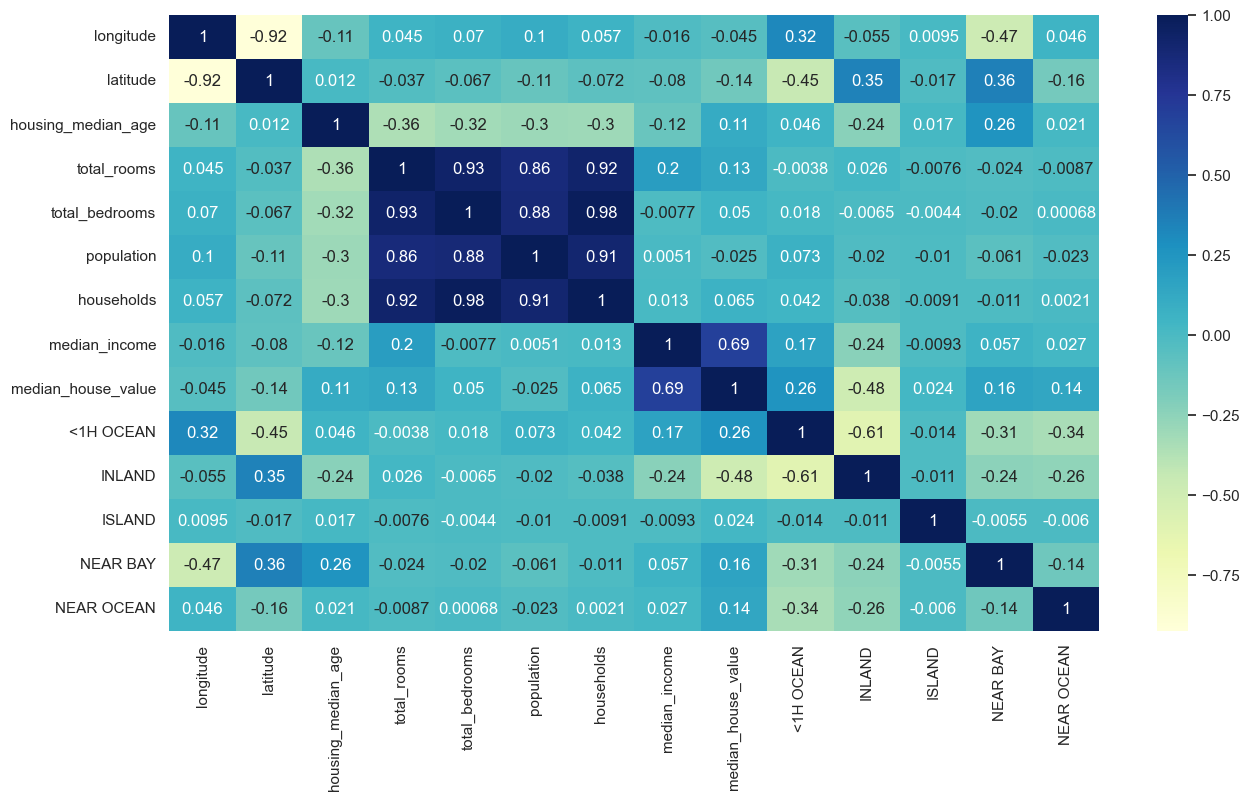

In [22]:
sb.set(rc={'figure.figsize':(15, 8)})
sb.heatmap(datos_na.corr(), annot=True, cmap="YlGnBu")